In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from sklearn.datasets import load_files

reviews_train = load_files('data/aclImdb/train/')
# 텍스트와 레이블을 포함하고 있는 Bunch 오브젝트를 반환합니다
text_train, y_train = reviews_train.data, reviews_train.target
print('text_train type:', type(text_train))
print('text_train length:', len(text_train))
print('text_train[6]:\n', text_train[6])

text_train type: <class 'list'>
text_train length: 75000
text_train[6]:
 b'Gloomy Sunday - Ein Lied von Liebe und Tod directed by Rolf Sch\xc3\xbcbel in 1999 is a romantic, absorbing, beautiful, and heartbreaking movie. It started like Jules and Jim; it ended as one of Agatha Christie\'s books, and in between it said something about love, friendship, devotion, jealousy, war, Holocaust, dignity, and betrayal, and it did better than The Black Book which is much more popular. It is not perfect, and it made me, a cynic, wonder in the end on the complexity of the relationships and sensational revelations, and who is who to whom but the movie simply overwhelmed me. Perfect or not, it is unforgettable. All four actors as the parts of the tragic not even a triangle but a rectangle were terrific. I do believe that three men could fell deeply for one girl as beautiful and dignified as Ilona in a star-making performance by young Hungarian actress Erica Marozs\xc3\xa1n and who would not? The titul

In [3]:
text_train = [doc.replace(b'<br />', b' ') for doc in text_train]

In [4]:
print('class per sample count (train data):', np.bincount(y_train))

class per sample count (train data): [12500 12500 50000]


In [5]:
reviews_test = load_files('data/aclImdb/test/')
text_test, y_test = reviews_test.data, reviews_test.target
print('test data doc count:', len(text_test))
print('class per sample count (test data):', np.bincount(y_test))
text_test = [doc.replace(b'<br />',b' ') for doc in text_test]

test data doc count: 25000
class per sample count (test data): [12500 12500]


In [6]:
bards_words = ['The fool doth think he is wise,',
               'but the wise man knows himself to be a fool']

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

In [8]:
print("word dict shape:", len(vect.vocabulary_))
print('word dict content:\n', vect.vocabulary_)

word dict shape: 13
word dict content:
 {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


In [9]:
bag_of_words = vect.transform(bards_words)
print('BOW:', repr(bag_of_words))

BOW: <2x13 sparse matrix of type '<class 'numpy.int64'>'
	with 16 stored elements in Compressed Sparse Row format>


In [10]:
print('BOW dense represent:\n', bag_of_words.toarray())

BOW dense represent:
 [[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


In [11]:
vect = CountVectorizer().fit(text_train)
x_train = vect.transform(text_train)
print('x_train:\n', repr(x_train))

x_train:
 <75000x124255 sparse matrix of type '<class 'numpy.int64'>'
	with 10315542 stored elements in Compressed Sparse Row format>


In [12]:
feature_names = vect.get_feature_names_out()
print('feature num:', len(feature_names))
print('first 20 feature:\n', feature_names[:20])
print('20010~20030 feature:\n', feature_names[20010:20030])
print('2000 feature:\n', feature_names[::2000])

feature num: 124255
first 20 feature:
 ['00' '000' '0000' '0000000000000000000000000000000001' '0000000000001'
 '000000001' '000000003' '00000001' '000001745' '00001' '0001' '00015'
 '0002' '0007' '00083' '000ft' '000s' '000th' '001' '002']
20010~20030 feature:
 ['cheapen' 'cheapened' 'cheapening' 'cheapens' 'cheaper' 'cheapest'
 'cheapie' 'cheapies' 'cheapjack' 'cheaply' 'cheapness' 'cheapo'
 'cheapozoid' 'cheapquels' 'cheapskate' 'cheapskates' 'cheapy' 'chearator'
 'cheat' 'cheata']
2000 feature:
 ['00' '_require_' 'aideed' 'announcement' 'asteroid' 'banquière'
 'besieged' 'bollwood' 'btvs' 'carboni' 'chcialbym' 'clotheth'
 'consecration' 'cringeful' 'deadness' 'devagan' 'doberman' 'duvall'
 'endocrine' 'existent' 'fetiches' 'formatted' 'garard' 'godlie' 'gumshoe'
 'heathen' 'honoré' 'immatured' 'interested' 'jewelry' 'kerchner' 'köln'
 'leydon' 'lulu' 'mardjono' 'meistersinger' 'misspells' 'mumblecore'
 'ngah' 'oedpius' 'overwhelmingly' 'penned' 'pleading' 'previlage'
 'quashed' 're

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(LogisticRegression(max_iter=1000), x_train, y_train, n_jobs=-1)
print('cross avg score: {:.2f}'.format(np.mean(scores)))

cross avg score: 0.69


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C':[0.001,0.01,0.1,1,10]}
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, n_jobs=-1)
grid.fit(x_train, y_train)
print('best cross score: {:.2f}'.format(grid.best_score_))
print('best parameter:', grid.best_params_)

In [13]:
vect = CountVectorizer(min_df=5).fit(text_train)
x_train = vect.transform(text_train)
print('min_df로 제한한 x_train:', repr(x_train))

min_df로 제한한 x_train: <75000x44532 sparse matrix of type '<class 'numpy.int64'>'
	with 10191240 stored elements in Compressed Sparse Row format>


In [14]:
feature_names = vect.get_feature_names_out()

print('처음 50개 특성 :\n', feature_names[:50])
print('20,010부터 20,030까지 특성 :\n', feature_names[20010:20030])
print('매 700번째 특성: \n', feature_names[::700])

처음 50개 특성 :
 ['00' '000' '001' '007' '00am' '00pm' '00s' '01' '02' '03' '04' '05' '06'
 '07' '08' '09' '10' '100' '1000' '1001' '100k' '100th' '100x' '101'
 '101st' '102' '103' '104' '105' '106' '107' '108' '109' '10am' '10pm'
 '10s' '10th' '10x' '11' '110' '1100' '110th' '111' '112' '1138' '115'
 '116' '117' '11pm' '11th']
20,010부터 20,030까지 특성 :
 ['inert' 'inertia' 'inescapable' 'inescapably' 'inevitability'
 'inevitable' 'inevitably' 'inexcusable' 'inexcusably' 'inexhaustible'
 'inexistent' 'inexorable' 'inexorably' 'inexpensive' 'inexperience'
 'inexperienced' 'inexplicable' 'inexplicably' 'inexpressive'
 'inextricably']
매 700번째 특성: 
 ['00' 'accountability' 'alienate' 'appetite' 'austen' 'battleground'
 'bitten' 'bowel' 'burton' 'cat' 'choreographing' 'collide' 'constipation'
 'creatively' 'dashes' 'descended' 'dishing' 'dramatist' 'ejaculation'
 'epitomize' 'extinguished' 'figment' 'forgot' 'garnished' 'goofy' 'gw'
 'hedy' 'hormones' 'imperfect' 'insomniac' 'janitorial' 'keira' 'la

In [15]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print('불용어 개수:', len(ENGLISH_STOP_WORDS))
print('매 10번째 불용어 :\n', list(ENGLISH_STOP_WORDS)[::10])

불용어 개수: 318
매 10번째 불용어 :
 ['once', 'without', 'mostly', 'his', 'through', 'per', 'hasnt', 'those', 'thru', 'will', 'due', 'where', 'elsewhere', 'same', 'everyone', 'fire', 'side', 'take', 'ours', 'was', 'anyone', 'amongst', 'throughout', 'ie', 'co', 'few', 'now', 'full', 'eg', 'thereafter', 'him', 'bottom']


In [16]:
# stop_words='english'라고 지정하면 내장된 불용어를 사용합니다
# 내장된 불용어에 추가할 수도 있고 자신만의 목록을 사용할 수도 있습니다
vect = CountVectorizer(min_df=5, stop_words='english').fit(text_train)
x_train = vect.transform(text_train)
print('불용어가 제거된 x_train:\n', repr(x_train))

불용어가 제거된 x_train:
 <75000x44223 sparse matrix of type '<class 'numpy.int64'>'
	with 6577418 stored elements in Compressed Sparse Row format>


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=5000))
param_grid = {'logisticregression__C':[0.001,0.01,0.1,1,10]}

grid = GridSearchCV(pipe, param_grid, n_jobs=-1)
grid.fit(text_train, y_train)
print('최상의 교차 검증 점수: {:.2f}'.format(grid.best_score_))

최상의 교차 검증 점수: 0.71


In [21]:
vectorizer = grid.best_estimator_.named_steps['tfidfvectorizer']
# 훈련 데이터셋을 변환합니다
x_train = vectorizer.transform(text_train)
# 특성별로 가장 큰 값을 찾습니다
max_value = x_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
# 특성 이름을 구합니다
faeture_names = np.array(vectorizer.get_feature_names_out())

print('가장 낮은 tfidf를 가진 특성:\n', feature_names[sorted_by_tfidf[:20]])
print('가장 높은 tfidf를 가진 특성:\n', feature_names[sorted_by_tfidf[-20:]])

가장 낮은 tfidf를 가진 특성:
 ['suplexes' 'acquiesce' 'avenged' 'invocus' 'bookcase' 'poffysmoviemania'
 'zantara' 'boozed' 'pragmatism' 'brutes' 'unrivalled' 'simpatico'
 'enrages' 'trumpeted' 'flowering' 'fearfully' 'reveries' 'décor'
 'authorial' 'clobber']
가장 높은 tfidf를 가진 특성:
 ['smallville' 'frasier' 'halloweentown' 'lupin' 'steve' 'tomie' 'stinks'
 'lucy' 'gta' 'scanners' 'doodlebops' 'skulls' 'ling' 'yadda' 'nr' 'ha'
 'pokemon' 'freakazoid' 'click' 'wicked']


In [22]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print('가장 낮은 idf를 가진 특성:\n', feature_names[sorted_by_idf[:100]])

가장 낮은 idf를 가진 특성:
 ['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'one' 'be' 'have' 'are' 'film' 'you' 'all'
 'at' 'an' 'by' 'from' 'so' 'like' 'who' 'there' 'they' 'his' 'if' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'can' 'good' 'when' 'more'
 'up' 'time' 'very' 'even' 'only' 'no' 'see' 'would' 'my' 'story' 'really'
 'which' 'well' 'had' 'me' 'than' 'their' 'much' 'were' 'get' 'other' 'do'
 'been' 'most' 'also' 'into' 'don' 'her' 'first' 'great' 'how' 'made'
 'people' 'will' 'make' 'because' 'way' 'could' 'bad' 'we' 'after' 'them'
 'too' 'any' 'then' 'movies' 'watch' 'she' 'think' 'seen' 'acting' 'its'
 'characters']


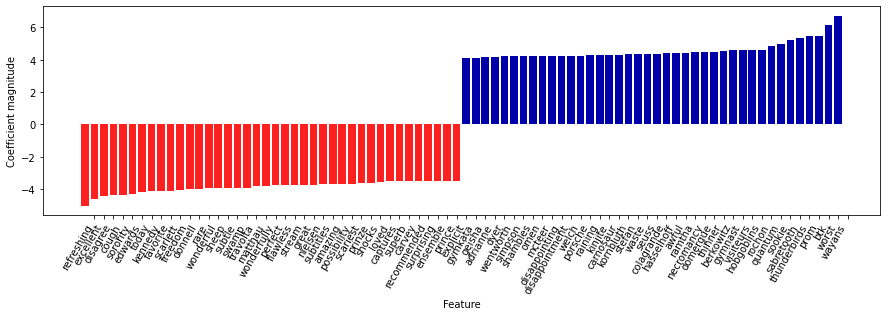

In [23]:
mglearn.tools.visualize_coefficients(
    grid.best_estimator_.named_steps['logisticregression'].coef_[0],
    feature_names, n_top_features=40)

In [24]:
print('bards_words:\n', bards_words)

bards_words:
 ['The fool doth think he is wise,', 'but the wise man knows himself to be a fool']


In [25]:
cv = CountVectorizer(ngram_range=(1,1)).fit(bards_words)
print('어휘 사전 크기:', len(cv.vocabulary_))
print('어휘 사전:\n', cv.get_feature_names_out())

어휘 사전 크기: 13
어휘 사전:
 ['be' 'but' 'doth' 'fool' 'he' 'himself' 'is' 'knows' 'man' 'the' 'think'
 'to' 'wise']


In [26]:
cv = CountVectorizer(ngram_range=(2,2)).fit(bards_words)
print('어휘 사전 크기:', len(cv.vocabulary_))
print('어휘 사전:\n', cv.get_feature_names_out())

어휘 사전 크기: 14
어휘 사전:
 ['be fool' 'but the' 'doth think' 'fool doth' 'he is' 'himself to'
 'is wise' 'knows himself' 'man knows' 'the fool' 'the wise' 'think he'
 'to be' 'wise man']


In [27]:
print('변환된 데이터 (밀집 배열): \n', cv.transform(bards_words).toarray())

변환된 데이터 (밀집 배열): 
 [[0 0 1 1 1 0 1 0 0 1 0 1 0 0]
 [1 1 0 0 0 1 0 1 1 0 1 0 1 1]]


In [28]:
cv = CountVectorizer(ngram_range=(1,3)).fit(bards_words)
print('어휘 사전 크기:', len(cv.vocabulary_))
print('어휘 사전:\n', cv.get_feature_names_out())

어휘 사전 크기: 39
어휘 사전:
 ['be' 'be fool' 'but' 'but the' 'but the wise' 'doth' 'doth think'
 'doth think he' 'fool' 'fool doth' 'fool doth think' 'he' 'he is'
 'he is wise' 'himself' 'himself to' 'himself to be' 'is' 'is wise'
 'knows' 'knows himself' 'knows himself to' 'man' 'man knows'
 'man knows himself' 'the' 'the fool' 'the fool doth' 'the wise'
 'the wise man' 'think' 'think he' 'think he is' 'to' 'to be' 'to be fool'
 'wise' 'wise man' 'wise man knows']


In [29]:
pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=5000))
# 매개변수 조합이 많고 트라이그램이 포함되어 있기 때문에 그리드 서치 실행에 시간이 오래 걸립니다
param_grid = {'logisticregression__C':[1,10,100],
              'tfidfvectorizer__ngram_range':[(1,1),(1,3)]}

grid = GridSearchCV(pipe, param_grid, n_jobs=-1)
grid.fit(text_train, y_train)
print('최상의 고차 검증 점수 : {:.2f}'.format(grid.best_score_))
print('최적의 매개변수 : \n', grid.best_params_)

최상의 고차 검증 점수 : 0.71
최적의 매개변수 : 
 {'logisticregression__C': 10, 'tfidfvectorizer__ngram_range': (1, 1)}


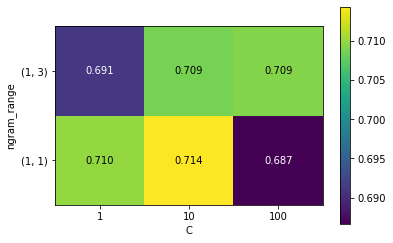

In [30]:
# 그리드 서치에서 테스트 점수를 추출합니다
scores = grid.cv_results_['mean_test_score'].reshape(-1,2).T
# 히트맵을 그립니다
heatmap = mglearn.tools.heatmap(
    scores, xlabel='C', ylabel='ngram_range', cmap='viridis', fmt='%.3f', xticklabels=param_grid['logisticregression__C'],
    yticklabels=param_grid['tfidfvectorizer__ngram_range'])
plt.colorbar(heatmap)

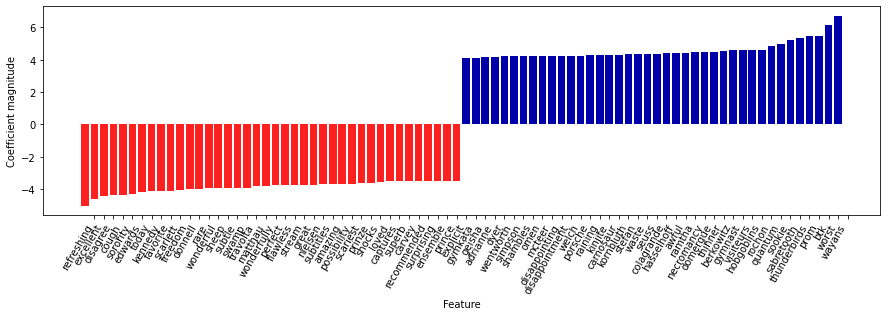

In [31]:
# 특성 이름과 계수를 추출합니다
vect = grid.best_estimator_.named_steps['tfidfvectorizer']
feature_names = np.array(vect.get_feature_names_out())
coef = grid.best_estimator_.named_steps['logisticregression'].coef_
mglearn.tools.visualize_coefficients(coef[0], feature_names, n_top_features=40)

In [32]:
import spacy
import nltk

# spacy의 영어 모델을 업로드합니다
en_nlp = spacy.load('en_core_web_sm')
# nltk의 PorterStemmer 객체를 만듭니다
stemmer = nltk.stem.PorterStemmer()

# spacy의 표제어 추출과 nltk의 어간 추출을 비교하는 함수입니다
def comparte_normalization(doc):
    # spacy로 문서를 토큰화합니다
    doc_spacy = en_nlp(doc)
    # spacy로 찾은 표제어를 출력합니다
    print('표제어:')
    print([token.lemma_ for token in doc_spacy])
    # PorterStemmer로 찾은 토큰을 출력합니다
    print('어간:')
    print([stemmer.stem(token.norm_.lower()) for token in doc_spacy])

In [33]:
comparte_normalization(u'Our meeting today was worse than yesterday, '
                         "I'm scared of meeting the clients tomorrow.")

표제어:
['our', 'meeting', 'today', 'be', 'bad', 'than', 'yesterday', ',', 'I', 'be', 'scared', 'of', 'meet', 'the', 'client', 'tomorrow', '.']
어간:
['our', 'meet', 'today', 'wa', 'wors', 'than', 'yesterday', ',', 'i', 'am', 'scare', 'of', 'meet', 'the', 'client', 'tomorrow', '.']


In [34]:
# 요구사항: spacy에서 표제어 추출 기능과 CountVectorizer의 토큰 분할기를 사용합니다

# spacy의 언어 모델을 로드합니다
en_nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])

# spacy 문서 처리 파이프라인을 사용해 자작 토큰 분할기를 만듭니다
# (우리만의 토큰 분할기를 사용합니다)
def custom_tokenizer(document):
    doc_spacy = en_nlp(document)
    return [token.lemma_ for token in doc_spacy]

# 자작 토큰 분할기를 사용해 CountVectorizer 객체를 만듭니다
lemma_vect = CountVectorizer(tokenizer=custom_tokenizer, min_df=5)

In [35]:
# 표제어 추출이 가능한 CountVectorizer 객체롤 text_train을 변환합니다
x_train_lemma = lemma_vect.fit_transform(text_train)
print('x_train_lemma.shape:', x_train_lemma.shape)

# 비교를 위해 표준 CountVectorizer를 사용합니다
vect = CountVectorizer(min_df=5).fit(text_train)
x_train = vect.transform(text_train)
print('x_train.shape:', x_train.shape)

x_train_lemma.shape: (75000, 36171)
x_train.shape: (75000, 44532)


In [39]:
# 훈련 세트의 1%만 사용해서 그리드 서치를 만듭니다
from sklearn.model_selection import StratifiedShuffleSplit

param_grid = {'C':[0.001,0.01,0.1,1,10]}
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.99, train_size=0.01, random_state=0)
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=cv, n_jobs=-1)

# 기본 CountVectorizer로 그리드 서치를 수행합니다
grid.fit(x_train, y_train)
print('최상의 교차 검증 점수 (기본 CountVectorizer): {:.3f}'.format(grid.best_score_))

# 표제어를 사용해서 그리드 서치를 수행합니다
grid.fit(x_train_lemma, y_train)
print('최상의 교차 검증 점수 (표제어): {:.3f}'.format(grid.best_score_))

최상의 교차 검증 점수 (기본 CountVectorizer): 0.666
최상의 교차 검증 점수 (표제어): 0.665


In [2]:
df_train = pd.read_csv('data/ratings_train.txt', delimiter='\t', keep_default_na=False)
df_train.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [3]:
text_train, y_train = df_train['document'].values, df_train['label'].values

In [4]:
df_test = pd.read_csv('data/ratings_test.txt', delimiter='\t', keep_default_na=False)
text_test, y_test = df_test['document'].values, df_test['label'].values

In [8]:
len(text_train), np.bincount(y_train)

(150000, array([75173, 74827], dtype=int64))

In [9]:
len(text_test), np.bincount(y_test)

(50000, array([24827, 25173], dtype=int64))

In [10]:
from konlpy.tag import Okt

class PicklableOkt(Okt):
    
    def __init__(self, *args):
        self.args = args
        Okt.__init__(self, *args)
        
    def __setstate__(self, state):
        self.__init__(*state['args'])
    
    def __getstate__(self):
        return {'args': self.args}
    
okt = PicklableOkt()

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

param_grid = {'tfidfvectorizer__min_df':[3,5,7],
              'tfidfvectorizer__ngram_range':[(1,1),(1,2),(1,3)],
              'logisticregression__C':[0.1,1,10]}
pipe = make_pipeline(TfidfVectorizer(tokenizer=okt.morphs),
                     LogisticRegression())
grid = GridSearchCV(pipe, param_grid, n_jobs=-1)

# 그리드 서치를 수행합니다
grid.fit(text_train[:1000], y_train[:1000])
print('최상의 교차 검증 점수: {:.3f}'.format(grid.best_score_))
print('최적의 교차 검증 매개변수:', grid.best_params_)

최상의 교차 검증 점수: 0.718
최적의 교차 검증 매개변수: {'logisticregression__C': 1, 'tfidfvectorizer__min_df': 3, 'tfidfvectorizer__ngram_range': (1, 3)}


In [12]:
tfidfvectorizer = grid.best_estimator_.named_steps['tfidfvectorizer']
x_test = tfidfvectorizer.transform(text_test[:1000])
logisticregression = grid.best_estimator_.named_steps['logisticregression']
score = logisticregression.score(x_test, y_test[:1000])
print('테스트 세트 점수: {:.3f}'.format(score))

테스트 세트 점수: 0.714


In [5]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer(max_features=10000, max_df=.15)
x = vect.fit_transform(text_train)

In [6]:
from sklearn.decomposition import LatentDirichletAllocation
lda = LatentDirichletAllocation(n_components=10, learning_method='batch', max_iter=25, random_state=0, n_jobs=-1)
# 모델 생성과 변환을 한 번에 합니다
# 변환 시간이 좀 걸리므로 시간을 절약하기 위해 동시에 처리합니다
document_topics = lda.fit_transform(x)

In [7]:
print('lda.components_.shape:', lda.components_.shape)

lda.components_.shape: (10, 10000)


In [8]:
# 토픽마다(components_의 행) 특성을 오름차순으로 정렬합니다
# 내림차순이 되도록 [:, ::-1] 사용해 행의 정렬을 반대로 바꿉니다
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
# CountVectorizer 객체에서 특성 이름을 구합니다
feature_names = np.array(vect.get_feature_names_out())

In [9]:
# 10개의 토픽을 출력합니다
mglearn.tools.print_topics(topics=range(10), feature_names=feature_names, sorting=sorting, topics_per_chunk=5, n_words=10)

topic 0       topic 1       topic 2       topic 3       topic 4       
--------      --------      --------      --------      --------      
너무            영화            너무            영화            영화를           
연기            평점이           봤는데           있는            많이            
없고            너무            정말            작품            다시            
스토리           정말            ㅋㅋㅋ           그리고           보고            
연기가           보면            재밌게           재밌다           봐도            
연기도           보고            ㅎㅎ            이야기           정말            
내용도           봤는데           그래도           대한            마지막           
스토리도          여운이           봤다            싶다            이런            
배우들           만든            재미있게          아름다운          영화가           
연출            오랜만에          근데            없는            영화의           


topic 5       topic 6       topic 7       topic 8       topic 9       
--------      --------      --------      --------      --------      
정말  

In [10]:
lda100 = LatentDirichletAllocation(n_components=100, learning_method='batch', max_iter=25, random_state=0, n_jobs=-1)
document_topics100 = lda100.fit_transform(x)

In [11]:
topics = np.array([7,16,24,25,28,36,37,41,45,51,53,54,63,89,97])

In [12]:
sorting = np.argsort(lda100.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names_out())
mglearn.tools.print_topics(topics=topics, feature_names=feature_names, sorting=sorting, topics_per_chunk=5, n_words=20)

topic 7       topic 16      topic 24      topic 25      topic 28      
--------      --------      --------      --------      --------      
많은            말이            최고            더럽게           영화            
아니고           영화            ㅎㅎ            재밌었어요         최악의           
모든            주는            뭐지            끝나고           제일            
영화            재밌는           재밌네요          쉽게            마음이           
것이            감동을           감동적이고         생각없이          지루한           
것을            기분            영화            잔인한           듯한            
생각을           삶을            왜케            티비에서          중에            
긴장감           있었던           가슴에           최고로           보여준           
공포            필요없는          펑펑            했으면           내가            
있음            만들어진          주기도           보고            했던            
하게            필요            괜찮다           새벽에           아무            
느끼게           불구하고          잠깐            오랫만에          따뜻해지는         
해준    

In [16]:
# 토픽 45를 가중치로 정렬합니다
music = np.argsort(document_topics100[:, 45])[::-1]
# 이 토픽이 가장 비중이 큰 문서 다섯개를 출력합니다
for i in music[:10]:
    # 첫 두 문장을 출력합니다
    print('.'.join(text_train[i].split('.')[:2]) + '.\n')

심도있는 척. 완성도 떨어지는 허세짙은 영화.

마이 시스터즈 키퍼와 같은 영화..

82년 영화인데 요즘 영화같지않게 잘만들었다.

배우들 연기도 OO인데다가 감독까지.

멋진스토리와 배우들 연기도 장난아니네요..

배우들 생긴게 왜 다 다운증후근 환자 같다.

주제의 높은 완성도.

우울하다. 갑갑하다.

이영화보니 한숨만 나온다..

한숨만 나온다.



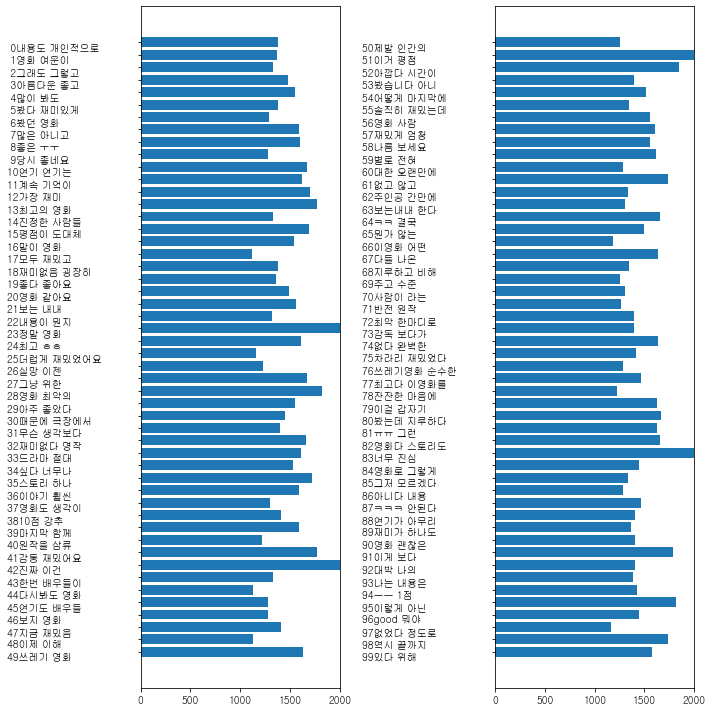

In [19]:
import matplotlib.pyplot as plt
 
# 한글 폰트 사용을 위해서 세팅
from matplotlib import font_manager, rc
font_path = "C:/Windows/Fonts/NGULIM.TTF"
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)

fig, ax = plt.subplots(1,2, figsize=(10,10))
topic_names = ['{:>2}'.format(i) +' '.join(words) for i, words in enumerate(feature_names[sorting[:, :2]])]
# 열이 두 개인 막대 그래프
for col in [0,1]:
    start = col * 50
    end = (col + 1) * 50
    ax[col].barh(np.arange(50), np.sum(document_topics100, axis=0)[start:end])
    ax[col].set_yticks(np.arange(50))
    ax[col].set_yticklabels(topic_names[start:end], ha='left', va='top')
    ax[col].invert_yaxis()
    ax[col].set_xlim(0, 2000)
    yax = ax[col].get_yaxis()
    yax.set_tick_params(pad=130)
plt.tight_layout()